In [1]:
from datetime import datetime

# U.S. Industry ETFs
us_industry_etfs = {
    "XLF": "Financials",                # Financial Select Sector SPDR Fund
    "XLK": "Technology",                # Technology Select Sector SPDR Fund
    "XLE": "Energy",                    # Energy Select Sector SPDR Fund
    "XLI": "Industrials",               # Industrial Select Sector SPDR Fund
    "XLU": "Utilities",                 # Utilities Select Sector SPDR Fund
    "XLP": "Consumer Staples",          # Consumer Staples Select Sector SPDR Fund
    "XLY": "Consumer Discretionary",    # Consumer Discretionary Select Sector SPDR Fund
    "XLV": "Health Care",               # Health Care Select Sector SPDR Fund
    "XLB": "Materials",                 # Materials Select Sector SPDR Fund
    "XLRE": "Real Estate"               # Real Estate Select Sector SPDR Fund
}

trading_days_in_year = 252
# Define the start and end dates for fetching the data
start_date = '1990-01-01'
end_date = datetime.today().strftime("%Y-%m-%d")

In [2]:
!pip install pandas yfinance matplotlib seaborn

In [3]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

returns_df = pd.DataFrame()

# Fetch daily returns for each ticker
for ticker, asset_class in us_industry_etfs.items():
    try:
        # Fetch historical data for the ticker
        data = yf.download(ticker)
        
        # Check if the data is empty
        if data.empty:
            print(f"No data found for ticker: {ticker}")
            continue
        
        # Calculate daily returns
        data['Daily Return'] = data['Adj Close'].pct_change()
        
        # Add the daily returns to the returns DataFrame
        data = data[['Daily Return']].rename(columns={'Daily Return': asset_class})
        if returns_df.empty:
            returns_df = data
        else:
            returns_df = returns_df.join(data, how='outer')
    except Exception as e:
        print(f"Failed for ticker: {ticker}")
        print(e)
        
# Drop the first row with NaN values
returns_df = returns_df.iloc[1:]
returns_df.to_csv("../data/historical-class-returns.csv")
# Display the first few rows of the returns DataFrame

# VERY IMPORTANT, OTHERWISE MANY COMPUTATIONS WOULD RETURN NONE, FROM 
# PORT OPT, to RISK CONT!
returns_df.fillna(0, inplace=True)
returns_df.head()

[*********************100%%**********************]  1 of 1 completed

[*********************100%%**********************]  1 of 1 completed

[*********************100%%**********************]  1 of 1 completed

[*********************100%%**********************]  1 of 1 completed

[*********************100%%**********************]  1 of 1 completed

...

[*********************100%%**********************]  1 of 1 completed

[*********************100%%**********************]  1 of 1 completed

[*********************100%%**********************]  1 of 1 completed


[*********************100%%**********************]  1 of 1 completed

,Financials,Technology,Energy,Industrials,Utilities,Consumer Staples,Consumer Discretionary,Health Care,Materials,Real Estate
Date,,,,,,,,,,
1998-12-23,0.014745,0.023891,0.020819,0.017450,-0.004190,0.024174,0.004295,0.022472,0.010502,0.0
1998-12-24,0.006605,-0.003810,-0.005263,0.013192,0.018411,-0.001727,0.018326,0.006105,0.023014,0.0
1998-12-28,-0.013123,0.002868,-0.005291,0.005208,-0.005164,-0.005767,-0.008998,-0.014563,-0.008709,0.0
1998-12-29,0.010638,0.002860,0.009974,0.014249,0.016615,0.022042,0.021792,0.022167,0.018302,0.0
1998-12-30,-0.003948,-0.003802,-0.015142,-0.004470,-0.008172,-0.006243,-0.008294,-0.008433,-0.002876,0.0


Previous example, notice how despite even weight allocation, risk contribution is diff per asset

/home/alan/Quantropy/src/portfolio_optimization.py:203: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  stored_weights_filled = stored_weights_shifted.ffill().fillna(0)


/home/alan/Quantropy/env/lib/python3.10/site-packages/pandas/core/frame.py:11211: RuntimeWarning: Degrees of freedom <= 0 for slice
  base_cov = np.cov(mat.T, ddof=ddof)
/home/alan/Quantropy/env/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/home/alan/Quantropy/env/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
/home/alan/Quantropy/src/portfolio_optimization.py:68: RuntimeWarning: invalid value encountered in divide
  return marginal_risk_contrib / portfolio_volatility


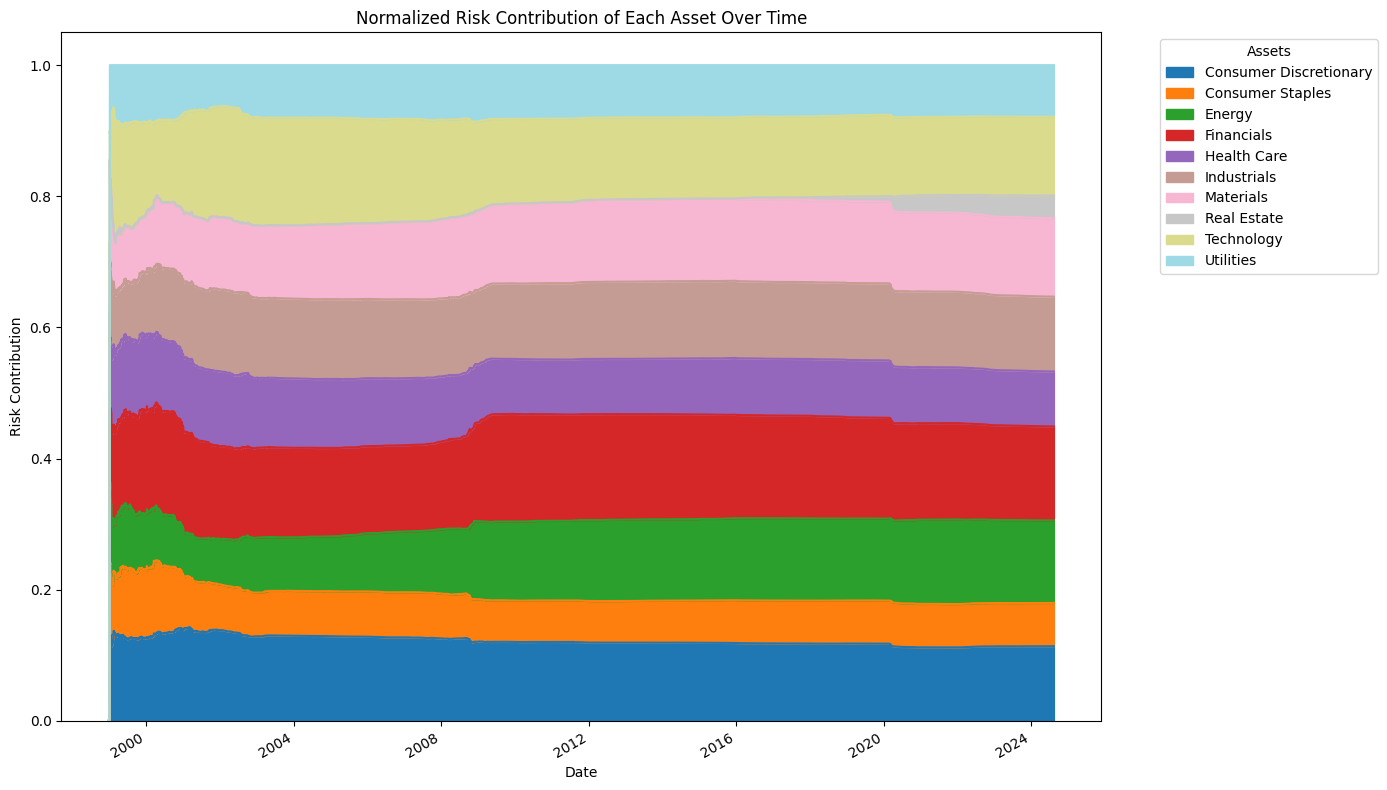

In [4]:
from portfolio_optimization import *
monthly_returns_df = (1 + returns_df).resample('ME').prod() - 1
# portfolio_returns = portfolio_allocation(returns_df, frequency='daily', method='eqCont')
# portfolio_returns = portfolio_allocation(returns_df, frequency='daily', method='minVol')
portfolio_returns, weights = portfolio_allocation(returns_df, frequency='daily', method='eqCont',
                                                               max_exposure=0.3)

post_processing = portfolio_performance(portfolio_returns=portfolio_returns, frequency="daily")
# Plot the risk contribution
plot_portfolio_risk_contribution_history(weights_df=weights, returns_df=returns_df)